In [1]:
import cv2

def get_video_length_opencv(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError("Could not open the video file.")
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    duration = frame_count / fps
    cap.release()
    return duration  # in seconds

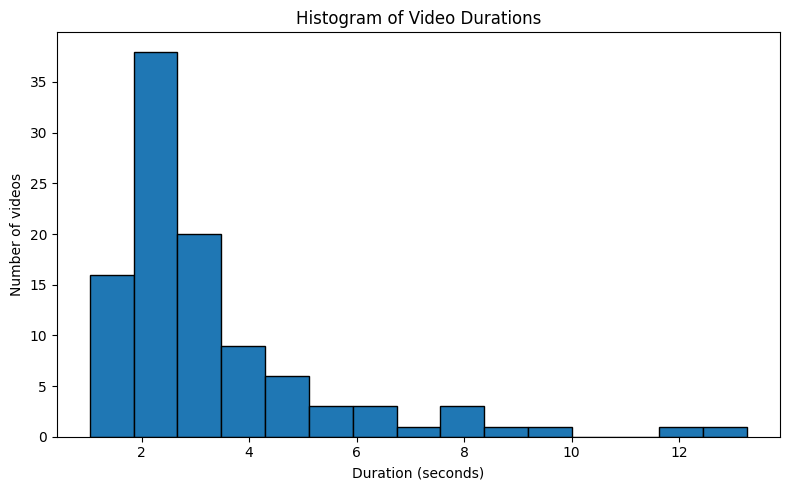

In [2]:
import os
from decord import VideoReader
import matplotlib.pyplot as plt

def plot_video_durations_histogram(dir_path, bins='auto'):
    """
    Walk through `dir_path`, read all .mp4 videos using decord,
    extract their durations (in seconds), and plot a histogram.
    """
    durations = []
    for root, _, files in os.walk(dir_path):
        for file in files:
            if file.lower().endswith('.mp4'):
                full_path = os.path.join(root, file)
                try:
                    vr = VideoReader(full_path)
                    fps = vr.get_avg_fps()
                    num_frames = len(vr)
                    duration_sec = num_frames / fps
                    durations.append(duration_sec)
                except Exception as e:
                    print(f"⚠️ Skipping {full_path}: {e}")

    if not durations:
        print("No .mp4 videos found in:", dir_path)
        return

    plt.figure(figsize=(8, 5))
    plt.hist(durations, bins=bins, edgecolor='black')
    plt.xlabel('Duration (seconds)')
    plt.ylabel('Number of videos')
    plt.title('Histogram of Video Durations')
    plt.tight_layout()
    plt.show()

# Example usage:
plot_video_durations_histogram("/gpfs/data/schambralab/quantitativeRehabilitation/__data/VideoDataDerived/FMVideoClips/clippedVideos/S0001")


In [2]:
video_data_path = "/gpfs/data/schambralab/quantitativeRehabilitation/__data/VideoData/rawVideosADLsandFM/"

from pathlib import Path
import os

def get_all_files_recursive(dir_path):
    files = []
    for root, _, filenames in os.walk(dir_path):
        for name in filenames:
            if "FM" in name:
                files.append(os.path.join(root, name))
    return files

files = get_all_files_recursive(video_data_path)
files = sorted(files)

In [3]:
def same_event(file1, file2):
    f1_pre = file1.split(".")[0][:-1]
    f2_pre = file2.split(".")[0][:-1]
    return f1_pre == f2_pre

In [4]:
pairs = []
for i in range(len(files) - 1):
    if same_event(files[i], files[i + 1]):
        pairs.append((files[i], files[i + 1]))

In [5]:
pairs[:2]

[('/gpfs/data/schambralab/quantitativeRehabilitation/__data/VideoData/rawVideosADLsandFM/C00011/C00011_FM left side1_1.avi',
  '/gpfs/data/schambralab/quantitativeRehabilitation/__data/VideoData/rawVideosADLsandFM/C00011/C00011_FM left side1_2.avi'),
 ('/gpfs/data/schambralab/quantitativeRehabilitation/__data/VideoData/rawVideosADLsandFM/C00011/C00011_FM left side2_1.avi',
  '/gpfs/data/schambralab/quantitativeRehabilitation/__data/VideoData/rawVideosADLsandFM/C00011/C00011_FM left side2_2.avi')]

In [6]:
from tqdm import tqdm

diffs = []
for file1, file2 in tqdm(pairs):
    length1 = get_video_length_opencv(file1)
    length2 = get_video_length_opencv(file2)
    diff = abs(length1 - length2)
    diffs.append(diff)

  0%|          | 0/267 [00:00<?, ?it/s]

100%|██████████| 267/267 [00:40<00:00,  6.55it/s]


In [7]:
import numpy as np
diffs = np.array(diffs)

In [8]:
len(diffs)

267

In [10]:
np.sort(diffs)[-40:]

array([ 0.06666667,  0.06666667,  0.06666667,  0.06666667,  0.06666667,
        0.06666667,  0.06666667,  0.06666667,  0.06666667,  0.06666667,
        0.06666667,  0.06666667,  0.06666667,  0.06666667,  0.06666667,
        0.08019802,  0.08333333,  0.08333333,  0.08333333,  0.08333333,
        0.08333333,  0.08333333,  0.08333333,  0.1       ,  0.1       ,
        0.26      ,  0.26      ,  0.26666667,  0.27      ,  0.27      ,
        0.27      ,  0.28      ,  0.28333333,  0.28333333,  0.28333333,
        0.28333333,  0.28333333,  0.3       , 17.23333333, 32.5       ])

In [13]:
import pandas as pd

df = pd.DataFrame({
    "diffs": diffs,
    "file1": [pair[0] for pair in pairs],
    "file2": [pair[1] for pair in pairs]
})


for i, line in df[df['diffs'] > 1].iterrows():
    print(line['diffs'], line['file1'])

17.233333333333327 /gpfs/data/schambralab/quantitativeRehabilitation/__data/VideoData/rawVideosADLsandFM/S00029/S00029_FM1_1.mkv
32.5 /gpfs/data/schambralab/quantitativeRehabilitation/__data/VideoData/rawVideosADLsandFM/S0009/S0009_FM2_1.avi


In [14]:
df.head()

,diffs,file1,file2
0,0.03,/gpfs/data/schambralab/quantitativeRehabilitat...,/gpfs/data/schambralab/quantitativeRehabilitat...
1,0.02,/gpfs/data/schambralab/quantitativeRehabilitat...,/gpfs/data/schambralab/quantitativeRehabilitat...
2,0.02,/gpfs/data/schambralab/quantitativeRehabilitat...,/gpfs/data/schambralab/quantitativeRehabilitat...
3,0.02,/gpfs/data/schambralab/quantitativeRehabilitat...,/gpfs/data/schambralab/quantitativeRehabilitat...
4,0.02,/gpfs/data/schambralab/quantitativeRehabilitat...,/gpfs/data/schambralab/quantitativeRehabilitat...


In [17]:
import re

matcher = lambda text: re.findall(r'\b[SC]\d+\b', text)[0]

df['file1'].apply(matcher).unique().tolist()

['C00011',
 'C00012',
 'C00015',
 'C00019',
 'C00020',
 'C00022',
 'C00023',
 'C00024',
 'C00025',
 'C00026',
 'C00027',
 'C00028',
 'C00029',
 'C00030',
 'C00031',
 'C0004',
 'C0005',
 'C0007',
 'C0009',
 'S0001',
 'S00010',
 'S00011',
 'S00012',
 'S00013',
 'S00016',
 'S00017',
 'S00018',
 'S00019',
 'S0002',
 'S00020',
 'S00021',
 'S00022',
 'S00023',
 'S00024',
 'S00025',
 'S00026',
 'S00027',
 'S00028',
 'S00029',
 'S0003',
 'S00030',
 'S00031',
 'S00032',
 'S00033',
 'S00034',
 'S00035',
 'S00036',
 'S00037',
 'S00039',
 'S0004',
 'S00040',
 'S00041',
 'S00042',
 'S00043',
 'S00044',
 'S00045',
 'S00046',
 'S00047',
 'S00048',
 'S00049',
 'S0005',
 'S00050',
 'S00051',
 'S00053',
 'S00054',
 'S00055',
 'S0006',
 'S0007',
 'S0008',
 'S0009']

In [12]:
df.head()

NameError: name 'df' is not defined

(array([3.833e+03, 2.500e+01, 6.000e+00, 4.000e+00, 3.000e+00, 3.000e+00,
        3.000e+00, 3.000e+00, 2.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00]),
 array([1.65016502e-03, 5.02555776e+00, 1.00494653e+01, 1.50733729e+01,
        2.00972805e+01, 2.51211881e+01, 3.01450957e+01, 3.51690033e+01,
        4.01929109e+01, 4.52168185e+01, 5.02407261e+01, 5.52646337e+01,
        6.02885413e+01, 6.53124488e+01, 7.03363564e+01, 7.53602640e+01,
        8.03841716e+01, 8.54080792e+01, 9.04319868e+01, 9.54558944e+01,
        1.004798

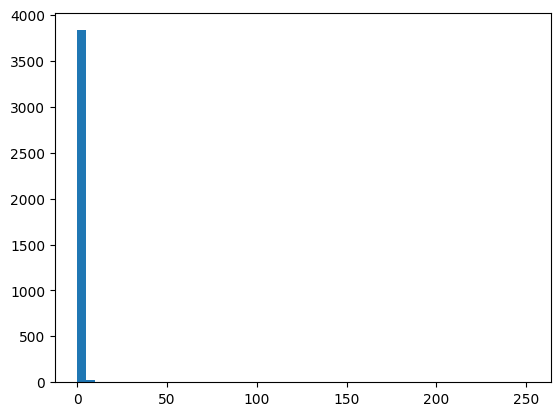

In [18]:
import matplotlib.pyplot as plt

plt.hist(diffs, bins=50)